# Noise-gen: real vs. generated, side-by-side

Loads the trained `PositionalHarmonicNoiseGen` (the *swapped* run) and the **full
DREGON / Michael's recordings as `TimeFrame`s**. Pick any recording and any
`(start, duration)` window — the notebook slices the recording, feeds its RPS +
array geometry through the model, and shows the **real** noise slice next to the
**generated** one (spectrograms, waveforms, RPS, multi-scale-STFT loss, and audio
players).

No `TimeFrameNoisePool` — you slice arbitrary windows of the original recordings
directly.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from data_processing.dregon import load_dregon_timeframes
from data_processing.michaels import load_michaels_timeframes
from data_processing.online_mixing import _extract_audio_array, interpolate_rps_to_stft_grid
from models.registry import build_noise_gen_loss, build_noise_gen_model
from tasks.noise_generation import DroneCodebook, geometry_to_rel_pos

SR = 16000
DEVICE = "cpu"  # 1 s slices render fine on CPU; set "cuda:0" if you prefer
CKPT = PROJECT_ROOT / "results/noise_gen_dregon_michaels_swapped/best_positional_harmonic_gen.pt"
print("checkpoint:", CKPT)

In [ ]:
# --- load model + external codebook from the bundle -------------------------------
bundle = torch.load(CKPT, map_location=DEVICE, weights_only=False)
print("bundle keys:", list(bundle), "| cond_dim:", bundle["cond_dim"], "| drones:", bundle["drone_names"])

model = build_noise_gen_model("positional_harmonic_gen", sample_rate=SR, n_harmonics=100, cond_dim=bundle["cond_dim"])
model.load_state_dict(bundle["model"])
model.to(DEVICE).eval()

codebook = DroneCodebook(bundle["cond_dim"], names=bundle["drone_names"]).to(DEVICE)
codebook.load_state_dict(bundle["codebook"])

# multi-scale STFT loss, matching the training default (for a quantitative number)
loss_fn = build_noise_gen_loss(
    stft_sizes=[2048, 1024, 512, 256, 128], log_weight=1.0, loss_type="L1",
).to(DEVICE)
print("params:", sum(p.numel() for p in model.parameters()))

In [3]:
# --- load the FULL recordings as TimeFrames (sliced arbitrarily below) ------------
# DREGON in_flight_noise (8ch, no download) + Michael's FLY124/FLY125.
_dregon = load_dregon_timeframes(
    PROJECT_ROOT / "data", splits=["in_flight_noise"], target_sr=SR, download=False
)
_michaels = load_michaels_timeframes(data_root=PROJECT_ROOT / "data", sr=SR)

RECORDINGS = {}  # friendly id -> {"tf", "drone"}
for tf in _dregon:
    RECORDINGS[f"dregon:{tf.tags['recording_id']}"] = {"tf": tf, "drone": "dregon"}
for tf in _michaels:
    RECORDINGS[f"michaels:FLY{tf.tags['recording_id']}"] = {"tf": tf, "drone": "michaels"}

print(f"{'recording id':45s} {'drone':9s} {'dur (s)':>8s}  rps mean (4 rotors)")
print("-" * 95)
for rid, e in RECORDINGS.items():
    tf = e["tf"]
    dur = tf["audio"].t_end - tf["audio"].t_start
    rps_mean = interpolate_rps_to_stft_grid(tf, n_frames=64, hop_length=int(dur * SR / 64)).mean(1)
    print(f"{rid:45s} {e['drone']:9s} {dur:8.1f}  {np.round(rps_mean, 1)}")

recording id                                  drone      dur (s)  rps mean (4 rotors)
-----------------------------------------------------------------------------------------------
dregon:free-flight_nosource_room1             dregon        71.1  [73.6 64.8 72.9 64.1]
dregon:free-flight_nosource_room2             dregon        81.6  [75.1 68.  73.4 70.5]
dregon:hovering_nosource_room2                dregon        44.9  [68.3 62.7 67.2 66.6]
dregon:updown_nosource_room2                  dregon        53.8  [74.2 69.1 73.1 72.5]
dregon:rectangle_nosource_room2               dregon        44.4  [68.6 62.9 66.9 65.1]
dregon:spinning_nosource_room2                dregon        40.6  [64.3 59.9 62.4 62.9]
michaels:FLY124                               michaels     121.6  [64.1 54.3 59.7 55.9]
michaels:FLY125                               michaels     177.5  [82.  67.4 75.  68.8]


/home/flyingleafe/Research/PhD/projects/harmonic-noise-suppression/data_processing/michaels.py:141: DtypeWarning: Columns (49,50,211,215,216,217,227) have mixed types. Specify dtype option on import or set low_memory=False.
  csv = pd.read_csv(csv_path)


In [4]:
# --- core: slice a recording window and render the model's noise ------------------
def render_slice(rec_id: str, start_s: float, dur_s: float = 1.0):
    """Slice [start_s, start_s+dur_s] of a recording (start_s relative to its start)
    and return the real target, the generated noise, and the conditioning RPS."""
    e = RECORDINGS[rec_id]
    tf, drone = e["tf"], e["drone"]
    t0 = tf["audio"].t_start
    avail = tf["audio"].t_end - t0
    if start_s < 0 or start_s + dur_s > avail:
        raise ValueError(f"{rec_id}: window [{start_s}, {start_s + dur_s}] outside [0, {avail:.1f}] s")

    sl = tf.slice(t0 + start_s, t0 + start_s + dur_s)
    n = int(round(dur_s * SR))
    target = _extract_audio_array(sl, target_len=n)                      # (M, T)
    rps = interpolate_rps_to_stft_grid(sl, n_frames=n, hop_length=1)     # (R, T) at audio rate
    gd = sl.global_data
    rel = geometry_to_rel_pos(gd["mic_positions"], gd["rotor_positions"])[: target.shape[0]]  # (M,R,3)

    z = codebook([drone])
    with torch.no_grad():
        pred = model(
            torch.from_numpy(rps)[None].to(DEVICE),
            torch.from_numpy(rel)[None].to(DEVICE),
            z,
        )[0].cpu().numpy()                                               # (M, T)
        # mic axis folded into batch, exactly like training
        loss = loss_fn(
            torch.from_numpy(pred).to(DEVICE), torch.from_numpy(target).to(DEVICE)
        ).item()
    return {
        "rec_id": rec_id, "drone": drone, "start_s": start_s, "dur_s": dur_s,
        "target": target, "pred": pred, "rps": rps, "rel": rel, "loss": loss,
    }


def _logspec(x, n_fft=1024, hop=256):
    X = torch.stft(torch.from_numpy(x).float(), n_fft=n_fft, hop_length=hop,
                   window=torch.hann_window(n_fft), return_complex=True)
    return 20 * np.log10(np.abs(X.numpy()) + 1e-6)


def compare(rec_id: str, start_s: float, dur_s: float = 1.0, mic: int = 0):
    """Plot real vs generated noise for one mic, plus RPS, and return audio players."""
    r = render_slice(rec_id, start_s, dur_s)
    tgt, prd, rps = r["target"][mic], r["pred"][mic], r["rps"]
    St, Sp = _logspec(tgt), _logspec(prd)
    vmax = max(St.max(), Sp.max()); vmin = vmax - 80

    fig, ax = plt.subplots(2, 2, figsize=(14, 7))
    fig.suptitle(f"{rec_id}  ({r['drone']})  t=[{start_s:.1f},{start_s+dur_s:.1f}] s  mic {mic}"
                 f"  |  msSTFT loss={r['loss']:.3f}", fontsize=12)
    for a, S, ttl in [(ax[0, 0], St, "REAL noise"), (ax[0, 1], Sp, "GENERATED noise")]:
        im = a.imshow(S, origin="lower", aspect="auto", vmin=vmin, vmax=vmax, cmap="magma",
                      extent=[0, dur_s, 0, SR / 2])
        a.set_title(ttl); a.set_ylabel("Hz"); a.set_xlabel("s")
        fig.colorbar(im, ax=a, format="%+0.0f dB")

    t = np.arange(len(tgt)) / SR
    ax[1, 0].plot(t, tgt, lw=0.5, label="real")
    ax[1, 0].plot(t, prd, lw=0.5, alpha=0.7, label="generated")
    ax[1, 0].set_title("waveform"); ax[1, 0].set_xlabel("s"); ax[1, 0].legend(loc="upper right")

    tr = np.arange(rps.shape[1]) / SR
    for i in range(rps.shape[0]):
        ax[1, 1].plot(tr, rps[i], lw=1.0, label=f"rotor {i}")
    ax[1, 1].set_title("conditioning RPS"); ax[1, 1].set_xlabel("s"); ax[1, 1].set_ylabel("Hz")
    ax[1, 1].legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

    print("REAL:");      display(Audio(tgt, rate=SR, normalize=True))
    print("GENERATED:"); display(Audio(prd, rate=SR, normalize=True))
    return r

### Example — DREGON
Edit `rec_id`, `start_s`, `dur_s`, `mic` and re-run.

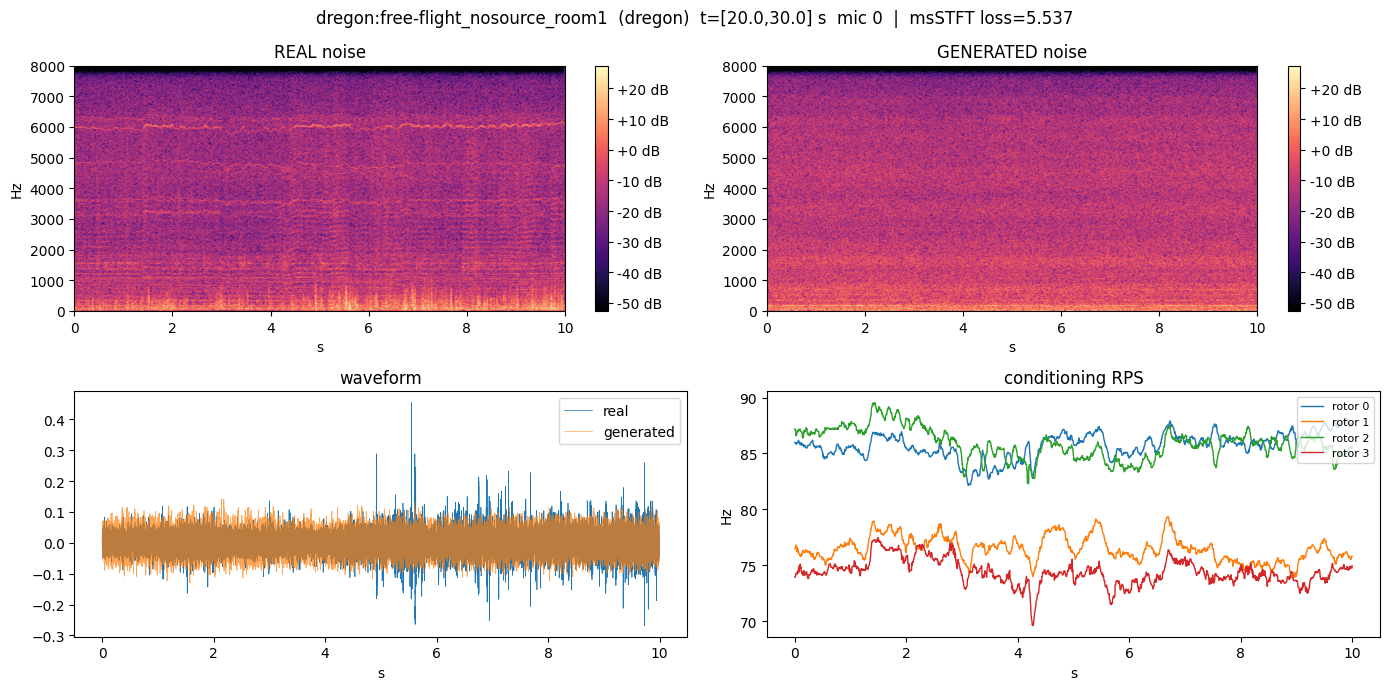

REAL:


GENERATED:


In [12]:
_ = compare("dregon:free-flight_nosource_room1", start_s=20.0, dur_s=10.0, mic=0)

### Example — Michael's (DJI Matrice 100)

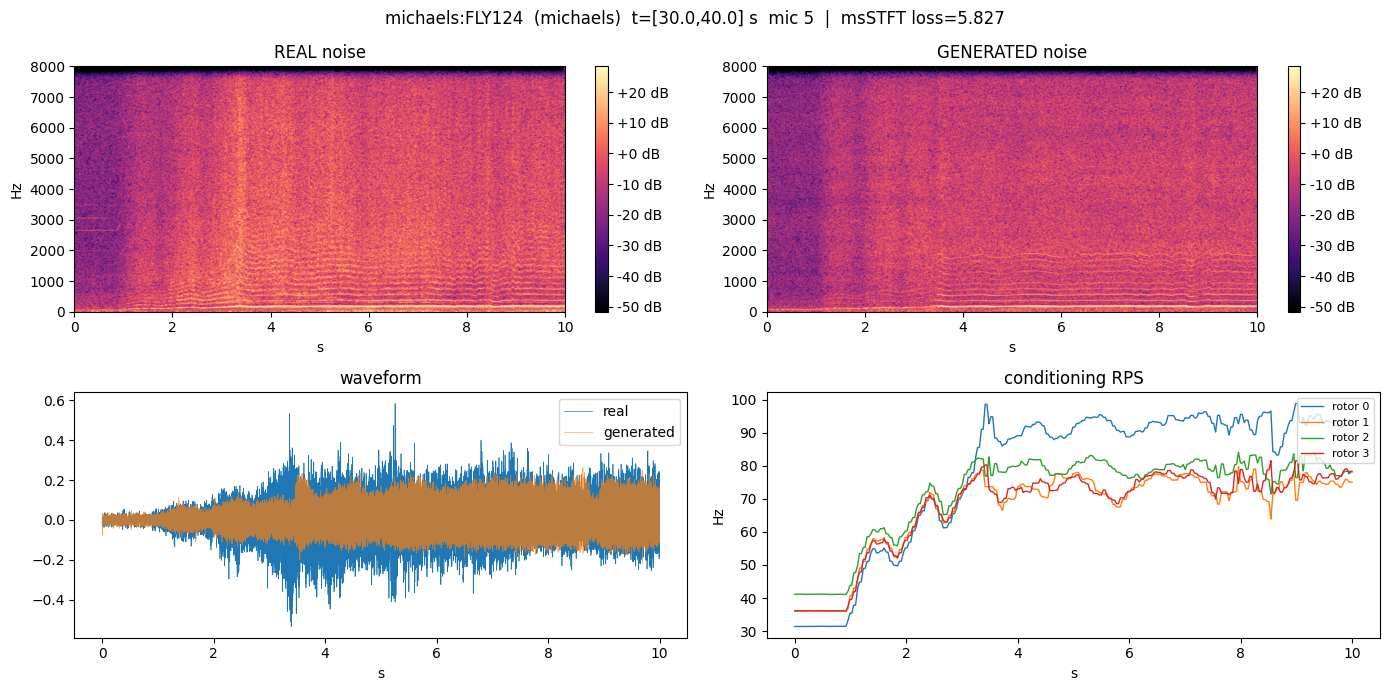

REAL:


GENERATED:


In [10]:
_ = compare("michaels:FLY124", start_s=30.0, dur_s=10.0, mic=5)

### Notes

- `start_s` is **relative to each recording's start**; valid range is `[0, dur]`
  from the inventory table above.
- `render_slice(...)` returns the raw arrays (`target`, `pred` `(M, T)`; `rps`
  `(R, T)`) if you want to do your own analysis or compare other mics.
- The model was conditioned per-drone via the external `DroneCodebook`
  (`codebook([drone])`). Loading the bundle restores both codes.
- Loss is the same multi-scale STFT magnitude loss used in training (mic axis
  folded into the batch); it is blind to a common delay but sees inter-rotor delay
  structure.